# 합성 시장상태 모델 실험

**날짜:** 2026-08-18  
**실행 환경:** `v3/.venv` (Python 3.12)  
**헬퍼:** `lib/joint_market_state.py`, `lib/kaggle_data.py`, `lib/drift.py`

이 노트북은 직접 수집한 42개 관측일(무신사·29CM)과 Favorita·M5 공개 수요 시계열을 **상대시간으로 합성 정렬**한 뒤, 전처리 형상·모델 입출력·상위 잠재 상관을 관측한다.

> **합성 정렬이지 인과 검증이 아니다.** Favorita(2013–2017)와 M5(2011–2016)의 날짜를 2026 수집일에 맞춘 것은 파이프라인·상관 민감도 샌드박스다. 같은 현실의 동시 변화를 증명하지 않는다. 모든 결합 행은 `synthetic_alignment=true`를 가진다.


## 0. 환경

카테고리 이름을 억지로 매핑하지 않는다. 결합하는 것은 성장률·변동성·집중도·mix drift처럼 도메인 공통인 상위 시장상태 지표뿐이다.


In [1]:
from __future__ import annotations

import json
import sys
import traceback
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

NB_ROOT = Path.cwd()
if not (NB_ROOT / "lib").exists():
    NB_ROOT = Path.cwd() / "notebooks"
sys.path.insert(0, str(NB_ROOT))

from lib.kaggle_data import load_favorita_panels, load_m5_panels
from lib.joint_market_state import (
    ALIGNMENT_METHOD,
    DEFAULT_FAVORITA_ANCHOR,
    DEFAULT_M5_ANCHOR,
    HORIZON_DAYS,
    PUBLIC_FEATURES,
    SILHOUETTE_FEATURES,
    SILHOUETTE_RUNS,
    TARGETS,
    attach_horizon_targets,
    build_joint_panel,
    feature_matrix,
    load_public_state,
    load_silhouette_state,
    load_survey_dates,
    permute_public_block,
    profile_frame,
    rolling_origin_indices,
    silhouette_column_catalog,
)
from lib.plotting import configure_matplotlib, finish_figure, format_date_axis

font = configure_matplotlib()
pd.set_option("display.max_columns", 24)
pd.set_option("display.width", 140)
print("NB_ROOT", NB_ROOT)
print("Python", sys.version.split()[0], "| font:", font)
print("RUNS_ROOT", SILHOUETTE_RUNS, "exists=", SILHOUETTE_RUNS.is_dir())
print("survey dates", len(load_survey_dates()), "| horizon", HORIZON_DAYS, "d")
print("alignment", ALIGNMENT_METHOD, "| fav_anchor", DEFAULT_FAVORITA_ANCHOR, "| m5_anchor", DEFAULT_M5_ANCHOR)

try:
    import sklearn
    from sklearn.decomposition import PCA
    from sklearn.ensemble import HistGradientBoostingRegressor
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import ElasticNet, LinearRegression
    from sklearn.metrics import mean_absolute_error
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler

    print("sklearn", sklearn.__version__)
except Exception as exc:
    sklearn = None
    print("sklearn import failed:", type(exc).__name__, exc)

try:
    import lightgbm as lgb

    print("lightgbm", lgb.__version__, "(nonlinear champion candidate)")
    HAS_LGB = True
except Exception:
    print("lightgbm not installed → HistGradientBoostingRegressor")
    HAS_LGB = False


NB_ROOT /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v3/notebooks
Python 3.12.2 | font: AppleGothic
RUNS_ROOT /Users/bhc/dev/datadrift/v2/silhouette_v2/runs exists= True
survey dates 42 | horizon 7 d
alignment relative_elapsed_from_seasonal_anchor | fav_anchor 2016-05-21 | m5_anchor 2015-05-21


sklearn 1.9.0
lightgbm not installed → HistGradientBoostingRegressor


## 1. 세 데이터층을 동일한 시장상태 계약으로 변환

직접 수집층은 `numeric_panel.json`(카테고리 share/entropy, 가격·할인), `analysis.json`(rank_energy), `drift_metric_points.json`(ranking turnover·review drift), visual diagnostics(신규·잔존·churn), `daily_scores.json`(statistical/text/visual headline)을 쓴다. **fused_signals.json(수십 MB)은 읽지 않는다.**


In [2]:
silhouette = load_silhouette_state(SILHOUETTE_RUNS)
print("silhouette shape", silhouette.shape)
print("run_date span", silhouette["run_date"].min().date(), "→", silhouette["run_date"].max().date())
print("elapsed_days max", float(silhouette["elapsed_days"].max()), "| n_dates", silhouette["run_date"].nunique())
print("panel_status")
display(silhouette["panel_status"].value_counts(dropna=False).to_frame("n"))
print("musinsa_status / cm29_status")
display(pd.crosstab(silhouette["musinsa_status"].fillna("NA"), silhouette["cm29_status"].fillna("NA")))
print("numeric_panel musinsa_n>0 days:", int((pd.to_numeric(silhouette["musinsa_n"], errors="coerce").fillna(0) > 0).sum()))
print("numeric_panel cm29_n>0 days:", int((pd.to_numeric(silhouette["cm29_n"], errors="coerce").fillna(0) > 0).sum()))
print("rank_energy days:", int(silhouette["musinsa_rank_energy_1d_mean"].notna().sum()))
print("ranking_turnover musinsa days:", int(silhouette["musinsa_ranking_turnover"].notna().sum()))

drop_preview = [c for c in silhouette.columns if c.startswith("_")]
sil_profile = profile_frame(silhouette.drop(columns=drop_preview, errors="ignore"), "silhouette")
print("컬럼 카탈로그 (형상 + 뜻). null_rate·nunique는 이 실행에서 관측된 값이다.")
display(silhouette_column_catalog(sil_profile))
print("상수·결측 주의")
display(
    silhouette_column_catalog(sil_profile).query("nunique <= 2 or null_rate >= 0.5")[
        ["column", "nunique", "null_rate", "meaning", "note"]
    ]
)
print("sample rows (provenance-relevant columns)")
display(
    silhouette[
        [
            "run_date",
            "gap_days",
            "musinsa_status",
            "musinsa_n",
            "musinsa_rank_energy_1d_mean",
            "musinsa_ranking_turnover",
            "musinsa_cat_entropy",
            "cm29_n",
            "cm29_ranking_turnover",
            "visual_new_rate",
            "drift_statistical",
            "drift_text",
            "drift_visual",
        ]
    ].head(8)
)


silhouette shape (42, 56)
run_date span 2026-05-21 → 2026-08-18
elapsed_days max 89.0 | n_dates 42
panel_status


,n
panel_status,
ok,31
insufficient_n,11


musinsa_status / cm29_status


cm29_status,insufficient_n,ok
musinsa_status,,
insufficient_n,11,12
ok,0,19


numeric_panel musinsa_n>0 days: 19
numeric_panel cm29_n>0 days: 31
rank_energy days: 42
ranking_turnover musinsa days: 41
컬럼 카탈로그 (형상 + 뜻). null_rate·nunique는 이 실행에서 관측된 값이다.


,column,dtype,non_null,null_rate,nunique,group,meaning,source,note
0,run_date,datetime64[us],42,0.000000,42,달력,직접 수집 관측일 (KST 기준 survey day),manifest / survey_days,42개 비연속 날짜
1,weekday,int64,42,0.000000,6,달력,요일 (월=0 … 일=6),run_date,nunique=6이면 일요일이 없는 수집 패턴
2,month,int64,42,0.000000,4,달력,월 (5–8),run_date,
3,gap_days,float64,41,0.023810,7,달력,직전 관측일과의 실제 간격(일),run_date diff,첫 날은 결측
4,panel_status,str,42,0.000000,2,품질,numeric_panel 전체 상태 (ok / insufficient_n),numeric_panel.json,한쪽 소스만 살아도 ok가 될 수 있음
5,musinsa_status,str,42,0.000000,2,품질,무신사 numeric_panel 상태,numeric_panel.json,ok는 2026-07-21부터 19일
6,musinsa_n,int64,42,0.000000,17,규모,무신사 numeric_panel 표본 수 (카테고리 share 분모),numeric_panel.json,0이면 카테고리 믹스 컬럼도 비어 있음
7,musinsa_top1,str,19,0.547619,2,구성,무신사 1위 카테고리 이름,numeric_panel.category_share,panel 부족 구간 결측
8,musinsa_top1_share,float64,19,0.547619,19,구성,무신사 1위 카테고리 점유율 (0–1),numeric_panel.category_share,
9,musinsa_cat_entropy,float64,19,0.547619,19,구성,무신사 카테고리 share 엔트로피. 높을수록 구성이 분산,category_share.shares,


상수·결측 주의


,column,nunique,null_rate,meaning,note
4,panel_status,2,0.000000,numeric_panel 전체 상태 (ok / insufficient_n),한쪽 소스만 살아도 ok가 될 수 있음
5,musinsa_status,2,0.000000,무신사 numeric_panel 상태,ok는 2026-07-21부터 19일
7,musinsa_top1,2,0.547619,무신사 1위 카테고리 이름,panel 부족 구간 결측
8,musinsa_top1_share,19,0.547619,무신사 1위 카테고리 점유율 (0–1),
9,musinsa_cat_entropy,19,0.547619,무신사 카테고리 share 엔트로피. 높을수록 구성이 분산,
10,musinsa_cat_hhi,19,0.547619,무신사 카테고리 HHI (점유율 제곱합). 높을수록 소수 카테고리 집중,
16,musinsa_mix_js,18,0.571429,직전 유효 관측 대비 무신사 카테고리 믹스 Jensen–Shannon. 구성 교체 강도,첫 유효일·panel 부족 구간 결측
17,cm29_status,2,0.000000,29CM numeric_panel 상태,ok는 2026-06-16부터
19,cm29_top1,1,0.261905,29CM 1위 카테고리 이름,관측 구간에서는 거의 항상 같은 라벨일 수 있음
25,cm29_discount_median,0,1.000000,29CM 할인율 중앙값,29CM panel이 할인을 안 내리면 전 구간 결측


sample rows (provenance-relevant columns)


,run_date,gap_days,musinsa_status,musinsa_n,musinsa_rank_energy_1d_mean,musinsa_ranking_turnover,musinsa_cat_entropy,cm29_n,cm29_ranking_turnover,visual_new_rate,drift_statistical,drift_text,drift_visual
0,2026-05-21,NaN,insufficient_n,0,0.505,NaN,NaN,0,NaN,0.000000,NaN,17.67112,NaN
1,2026-05-22,1.0,insufficient_n,0,0.505,0.537210,NaN,0,NaN,0.558939,0.356142,4.77102,0.05045
2,2026-05-26,4.0,insufficient_n,0,0.505,0.626075,NaN,0,NaN,0.536316,0.375102,5.04006,0.05030
3,2026-05-27,1.0,insufficient_n,0,0.505,0.640433,NaN,0,NaN,0.474024,0.620600,5.61302,0.00050
4,2026-06-01,5.0,insufficient_n,0,0.505,0.711197,NaN,0,NaN,0.548923,0.711197,6.65812,0.00040
5,2026-06-02,1.0,insufficient_n,0,0.505,0.715373,NaN,0,NaN,0.492567,0.715373,7.51420,0.00030
6,2026-06-05,3.0,insufficient_n,0,0.505,0.751710,NaN,0,NaN,0.581426,0.751710,8.35330,0.00070
7,2026-06-08,3.0,insufficient_n,0,0.505,0.774963,NaN,0,NaN,0.552326,0.774963,9.18046,0.05025


Favorita는 일별 `sales`·`promo_rate`·family/store mix entropy·JS, M5는 `units`·category/state mix entropy·JS·변동성이다. 패밀리명과 패션 카테고리를 1:1로 잇지 않는다.


In [3]:
fav_raw = load_favorita_panels()
m5_raw = load_m5_panels()
print("Favorita panels")
for k, df in fav_raw.items():
    print(f"  {k:18s} {tuple(df.shape)} index={df.index.name} cols={list(df.columns)[:6]}")
print("M5 panels")
for k, df in m5_raw.items():
    print(f"  {k:18s} {tuple(df.shape)} index={df.index.name} cols={list(df.columns)[:6]}")

fav_state, m5_state = load_public_state(fav_raw, m5_raw)
print("\nFavorita state", fav_state.shape, fav_state.index.min().date(), "→", fav_state.index.max().date())
print("M5 state", m5_state.shape, m5_state.index.min().date(), "→", m5_state.index.max().date())
display(profile_frame(fav_state.reset_index(), "favorita_state").head(20))
display(profile_frame(m5_state.reset_index(), "m5_state"))
print("Favorita sample")
display(fav_state.head(3))
print("M5 sample")
display(m5_state.head(3))


Favorita panels
  daily_total        (1684, 1) index=date cols=['sales']
  daily_family       (1684, 33) index=date cols=['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY']
  daily_store        (1684, 13) index=date cols=['Other', 'store_3', 'store_7', 'store_8', 'store_11', 'store_44']
  daily_promo_rate   (1684, 1) index=date cols=['promo_rate']
  tx_daily           (1682, 1) index=date cols=['transactions']
M5 panels
  daily_total        (1941, 1) index=date cols=['units']
  daily_cat          (1941, 3) index=date cols=['FOODS', 'HOBBIES', 'HOUSEHOLD']
  daily_state        (1941, 3) index=date cols=['CA', 'TX', 'WI']
  series_meta        (30490, 6) index=None cols=['unique_id', 'item', 'dept', 'cat', 'store', 'state']



Favorita state (1684, 9) 2013-01-01 → 2017-08-15
M5 state (1941, 7) 2011-01-29 → 2016-05-22


,table,column,dtype,non_null,null_rate,nunique
0,favorita_state,date,datetime64[us],1684,0.000000,1684
1,favorita_state,sales,float64,1684,0.000000,1684
2,favorita_state,sales_growth,float64,1683,0.000594,1683
3,favorita_state,sales_vol_7,float64,1681,0.001781,1681
4,favorita_state,promo_rate,float64,1684,0.000000,1160
5,favorita_state,transactions,float64,1682,0.001188,1648
6,favorita_state,family_entropy,float64,1684,0.000000,1684
7,favorita_state,family_mix_js,float64,1683,0.000594,1683
8,favorita_state,family_hhi,float64,1684,0.000000,1684
9,favorita_state,store_entropy,float64,1684,0.000000,1680


,table,column,dtype,non_null,null_rate,nunique
0,m5_state,date,datetime64[us],1941,0.000000,1941
1,m5_state,units,int64,1941,0.000000,1885
2,m5_state,units_growth,float64,1940,0.000515,1940
3,m5_state,units_vol_7,float64,1938,0.001546,1938
4,m5_state,cat_entropy,float64,1941,0.000000,1938
5,m5_state,cat_mix_js,float64,1940,0.000515,1940
6,m5_state,state_entropy,float64,1941,0.000000,1941
7,m5_state,state_mix_js,float64,1940,0.000515,1940


Favorita sample


,sales,sales_growth,sales_vol_7,promo_rate,transactions,family_entropy,family_mix_js,family_hhi,store_entropy
date,,,,,,,,,
2013-01-01,2511.618999,NaN,NaN,0.0,770.0,1.995833,NaN,0.201204,-0.000000
2013-01-02,496092.417944,5.285439,NaN,0.0,93215.0,1.962311,0.045687,0.220224,1.919286
2013-01-03,361461.231124,-0.316607,NaN,0.0,78504.0,1.972543,0.000234,0.216325,1.839740


M5 sample


,units,units_growth,units_vol_7,cat_entropy,cat_mix_js,state_entropy,state_mix_js
date,,,,,,,
2011-01-29,32631,NaN,NaN,0.796629,NaN,1.076134,NaN
2011-01-30,31749,-0.027401,NaN,0.783052,0.000119,1.074859,0.000173
2011-01-31,23783,-0.288880,NaN,0.778604,0.000173,1.080389,0.000529


## 2. 상대시간 합성 정렬과 provenance

수집일의 **실제 간격(`elapsed_days`)**을 보존한다. 첫 관측일 2026-05-21을 Favorita 2016-05-21, M5 2015-05-21 계절 앵커에 대응시킨 뒤 as-of lookup한다. 결합 테이블은 `synthetic_date`, `source_date_fav`, `source_date_m5`, `alignment_offset`, `alignment_method`, `synthetic_alignment=true`를 유지한다.


BEFORE align  silhouette (42, 56) favorita_state (1684, 9) m5_state (1941, 7)
AFTER align   joint (42, 84)
alignment_method ['relative_elapsed_from_seasonal_anchor']
alignment_offset [0]
favorita_anchor 2016-05-21 | m5_anchor 2015-05-21
provenance head


,synthetic_date,run_date,elapsed_days,source_date_fav,requested_source_date_fav,fav_asof_lag_days,source_date_m5,requested_source_date_m5,m5_asof_lag_days,alignment_offset,alignment_method,synthetic_alignment
0,2026-05-21,2026-05-21,0.0,2016-05-21,2016-05-21,0.0,2015-05-21,2015-05-21,0.0,0,relative_elapsed_from_seasonal_anchor,True
1,2026-05-22,2026-05-22,1.0,2016-05-22,2016-05-22,0.0,2015-05-22,2015-05-22,0.0,0,relative_elapsed_from_seasonal_anchor,True
2,2026-05-26,2026-05-26,5.0,2016-05-26,2016-05-26,0.0,2015-05-26,2015-05-26,0.0,0,relative_elapsed_from_seasonal_anchor,True
3,2026-05-27,2026-05-27,6.0,2016-05-27,2016-05-27,0.0,2015-05-27,2015-05-27,0.0,0,relative_elapsed_from_seasonal_anchor,True
4,2026-06-01,2026-06-01,11.0,2016-06-01,2016-06-01,0.0,2015-06-01,2015-06-01,0.0,0,relative_elapsed_from_seasonal_anchor,True
5,2026-06-02,2026-06-02,12.0,2016-06-02,2016-06-02,0.0,2015-06-02,2015-06-02,0.0,0,relative_elapsed_from_seasonal_anchor,True
6,2026-06-05,2026-06-05,15.0,2016-06-05,2016-06-05,0.0,2015-06-05,2015-06-05,0.0,0,relative_elapsed_from_seasonal_anchor,True
7,2026-06-08,2026-06-08,18.0,2016-06-08,2016-06-08,0.0,2015-06-08,2015-06-08,0.0,0,relative_elapsed_from_seasonal_anchor,True


provenance tail


,synthetic_date,run_date,elapsed_days,source_date_fav,requested_source_date_fav,fav_asof_lag_days,source_date_m5,requested_source_date_m5,m5_asof_lag_days,alignment_offset,alignment_method,synthetic_alignment
38,2026-08-11,2026-08-11,82.0,2016-08-11,2016-08-11,0.0,2015-08-11,2015-08-11,0.0,0,relative_elapsed_from_seasonal_anchor,True
39,2026-08-13,2026-08-13,84.0,2016-08-13,2016-08-13,0.0,2015-08-13,2015-08-13,0.0,0,relative_elapsed_from_seasonal_anchor,True
40,2026-08-14,2026-08-14,85.0,2016-08-14,2016-08-14,0.0,2015-08-14,2015-08-14,0.0,0,relative_elapsed_from_seasonal_anchor,True
41,2026-08-18,2026-08-18,89.0,2016-08-18,2016-08-18,0.0,2015-08-18,2015-08-18,0.0,0,relative_elapsed_from_seasonal_anchor,True


fav asof lag describe


,fav_asof_lag_days
count,42.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


public block null rates


,table,column,dtype,non_null,null_rate,nunique
0,joint_public,fav_asof_lag_days,float64,42,0.0,1
1,joint_public,fav_sales,float64,42,0.0,42
2,joint_public,fav_sales_growth,float64,42,0.0,42
3,joint_public,fav_sales_vol_7,float64,42,0.0,42
4,joint_public,fav_promo_rate,float64,42,0.0,42
5,joint_public,fav_transactions,float64,42,0.0,42
6,joint_public,fav_family_entropy,float64,42,0.0,42
7,joint_public,fav_family_mix_js,float64,42,0.0,42
8,joint_public,fav_family_hhi,float64,42,0.0,42
9,joint_public,fav_store_entropy,float64,42,0.0,42


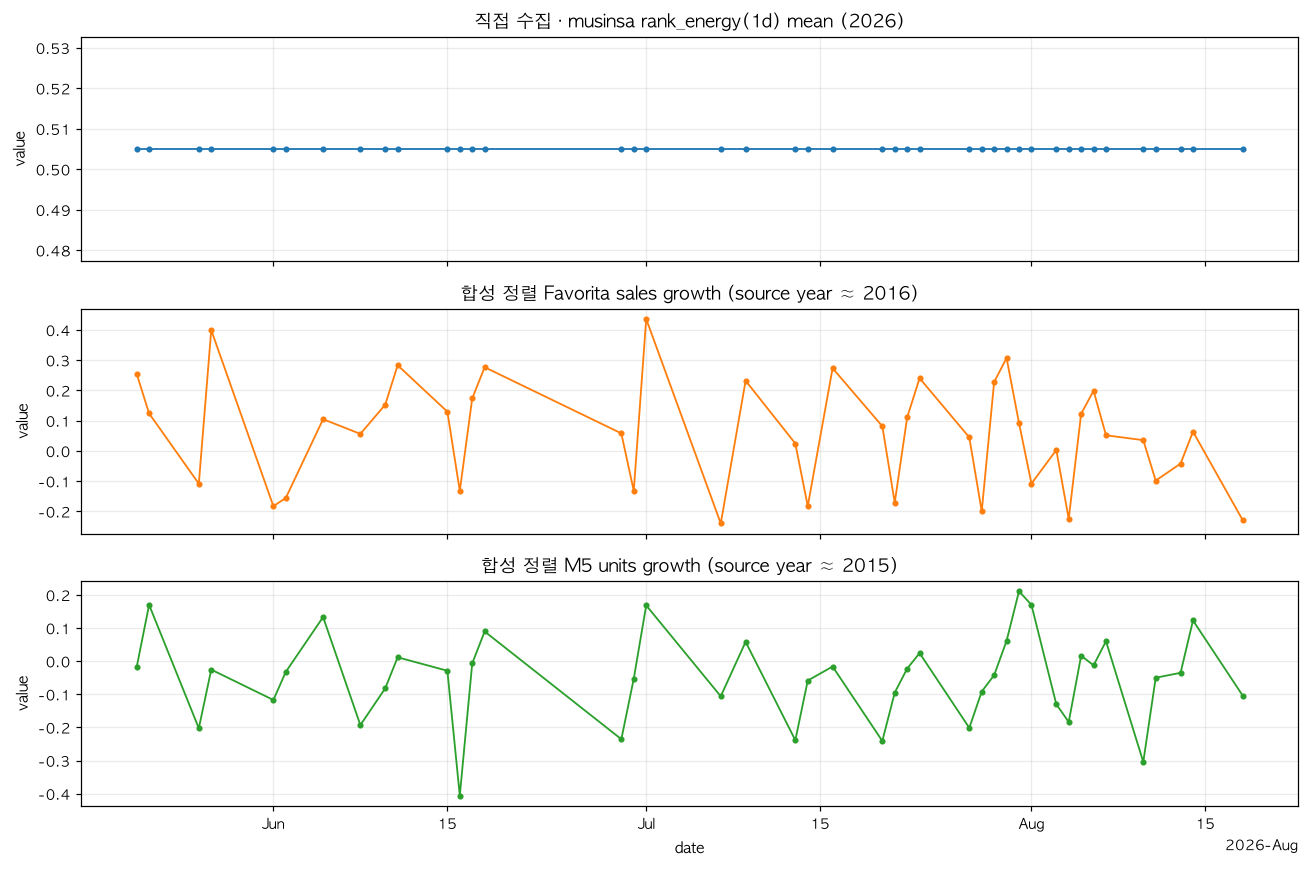

In [4]:
print("BEFORE align  silhouette", silhouette.shape, "favorita_state", fav_state.shape, "m5_state", m5_state.shape)
joint = build_joint_panel(silhouette, fav_state, m5_state, offset_days=0)
print("AFTER align   joint", joint.shape)
assert bool(joint["synthetic_alignment"].all())
print("alignment_method", joint["alignment_method"].unique().tolist())
print("alignment_offset", joint["alignment_offset"].unique().tolist())
print("favorita_anchor", joint["favorita_anchor"].iloc[0], "| m5_anchor", joint["m5_anchor"].iloc[0])

prov = joint[
    [
        "synthetic_date",
        "run_date",
        "elapsed_days",
        "source_date_fav",
        "requested_source_date_fav",
        "fav_asof_lag_days",
        "source_date_m5",
        "requested_source_date_m5",
        "m5_asof_lag_days",
        "alignment_offset",
        "alignment_method",
        "synthetic_alignment",
    ]
]
print("provenance head")
display(prov.head(8))
print("provenance tail")
display(prov.tail(4))
print("fav asof lag describe")
display(joint["fav_asof_lag_days"].describe().to_frame("fav_asof_lag_days"))
print("public block null rates")
pub_cols = [c for c in joint.columns if c.startswith("fav_") or c.startswith("m5_")]
display(profile_frame(joint[pub_cols], "joint_public"))

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(joint["synthetic_date"], joint["musinsa_rank_energy_1d_mean"], marker="o", ms=3)
axes[0].set_title("직접 수집 · musinsa rank_energy(1d) mean (2026)")
axes[1].plot(joint["synthetic_date"], joint["fav_sales_growth"], marker="o", ms=3, color="C1")
axes[1].set_title("합성 정렬 Favorita sales growth (source year ≈ 2016)")
axes[2].plot(joint["synthetic_date"], joint["m5_units_growth"], marker="o", ms=3, color="C2")
axes[2].set_title("합성 정렬 M5 units growth (source year ≈ 2015)")
for ax in axes:
    ax.set_ylabel("value")
finish_figure(fig, axes, date_axis=True)


## 3. 타깃 · 시간순 split · 3계층 모델

- Persistence: 직전 관측값 반복 (최소 기준선)
- ElasticNet: 방향·계수 해석이 가능한 선형 결합. Imputer·Scaler는 **해당 fold의 train에만** fit
- HistGradientBoosting: 비선형·결측 허용 비교 (LightGBM 미설치 시)
- 별도 기술 분석: PCA 1–2요인 (예측 파이프라인의 PCA와 분리)

타깃은 `y_rank_mix_proxy`(가능하면 t→t+7 카테고리 mix JS, 아니면 미래 ranking turnover), `y_future_drift_score`, 합성 샌드박스 `y_future_sales_growth`로 분리한다. 최근 7일 안쪽은 label incomplete다.


labeled shape (42, 94) | label_ready 39
  y_rank_mix_proxy             non-null 39  null_rate=0.07
  y_future_drift_score         non-null 39  null_rate=0.07
  y_future_sales_growth        non-null 39  null_rate=0.07

X shape (42, 42) n_features 42
feature names: ['weekday', 'month', 'gap_days', 'elapsed_days', 'musinsa_n', 'musinsa_top1_share', 'musinsa_cat_entropy', 'musinsa_cat_hhi', 'musinsa_mix_js', 'musinsa_price_median', 'musinsa_discount_median', 'musinsa_rank_energy_1d_mean', 'musinsa_rank_energy_sustained_mean', 'musinsa_momentum_span_mean', 'musinsa_ranking_turnover', 'musinsa_review_drift', 'cm29_n', 'cm29_top1_share', 'cm29_cat_entropy', 'cm29_mix_js', 'cm29_price_median', 'cm29_ranking_turnover', 'cm29_review_drift', 'visual_js_mean', 'visual_new_rate', 'visual_churn_rate', 'visual_mean_nn_new', 'drift_statistical', 'drift_text', 'drift_visual', 'fav_sales_growth', 'fav_sales_vol_7', 'fav_promo_rate', 'fav_family_entropy', 'fav_family_mix_js', 'fav_family_hhi', 'fav_store

,table,column,dtype,non_null,null_rate,nunique
0,X,weekday,int64,42,0.000000,6
1,X,month,int64,42,0.000000,4
2,X,gap_days,float64,41,0.023810,7
3,X,elapsed_days,float64,42,0.000000,42
4,X,musinsa_n,int64,42,0.000000,17
5,X,musinsa_top1_share,float64,19,0.547619,19
6,X,musinsa_cat_entropy,float64,19,0.547619,19
7,X,musinsa_cat_hhi,float64,19,0.547619,19
8,X,musinsa_mix_js,float64,18,0.571429,18
9,X,musinsa_price_median,float64,42,0.000000,39


one input row (raw features, last labeled)


,x_last
weekday,1.000000
month,8.000000
gap_days,1.000000
elapsed_days,82.000000
musinsa_n,507.000000
musinsa_top1_share,0.234714
musinsa_cat_entropy,2.096300
musinsa_cat_hhi,0.147104
musinsa_mix_js,0.013631
musinsa_price_median,85990.000000


corresponding y


,38
run_date,2026-08-11 00:00:00
target_date,2026-08-18 00:00:00
y_rank_mix_proxy,0.021738
y_future_drift_score,0.76536
y_future_sales_growth,-0.033014


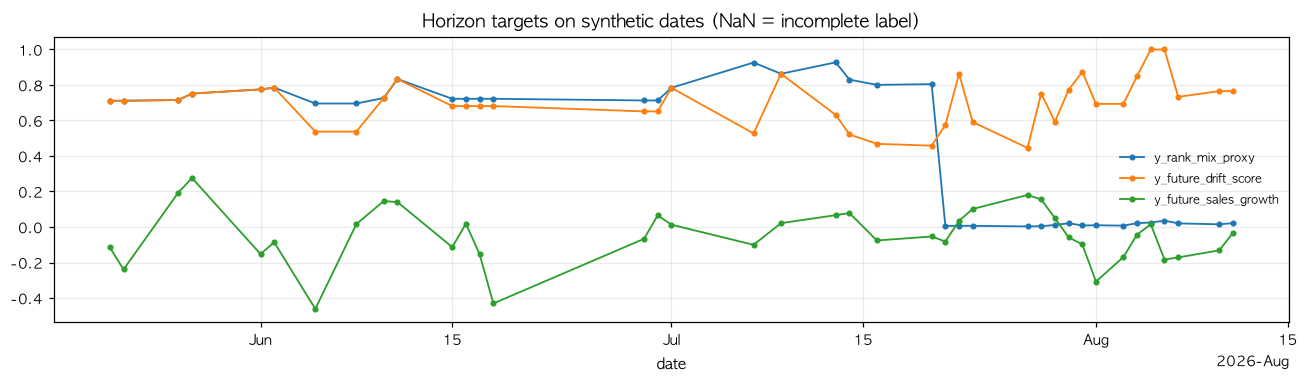

In [5]:
labeled = attach_horizon_targets(joint, horizon_days=HORIZON_DAYS)
print("labeled shape", labeled.shape, "| label_ready", int(labeled["label_ready"].sum()))
for col in TARGETS:
    print(f"  {col:28s} non-null {int(labeled[col].notna().sum())}  null_rate={labeled[col].isna().mean():.2f}")

x_all, feat_names = feature_matrix(labeled, include_public=True)
print("\nX shape", x_all.shape, "n_features", len(feat_names))
print("feature names:", feat_names)
display(profile_frame(x_all, "X"))
print("one input row (raw features, last labeled)")
ready = labeled[labeled["label_ready"]].reset_index(drop=True)
x_ready, _ = feature_matrix(ready, include_public=True)
display(x_ready.iloc[[-1]].T.rename(columns={x_ready.index[-1]: "x_last"}))
print("corresponding y")
display(ready.iloc[[-1]][["run_date", "target_date", *TARGETS]].T)

fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(labeled["run_date"], labeled["y_rank_mix_proxy"], marker="o", ms=3, label="y_rank_mix_proxy")
ax.plot(labeled["run_date"], labeled["y_future_drift_score"], marker="o", ms=3, label="y_future_drift_score")
ax.plot(labeled["run_date"], labeled["y_future_sales_growth"], marker="o", ms=3, label="y_future_sales_growth")
ax.legend(frameon=False)
ax.set_title("Horizon targets on synthetic dates (NaN = incomplete label)")
finish_figure(fig, ax, date_axis=True)


In [6]:
def _spearman(a, b) -> float:
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3:
        return np.nan
    rho, _ = stats.spearmanr(a[mask], b[mask])
    return float(rho)


def _dir_acc(y_true, y_pred) -> float:
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.sign(y_true[mask]) == np.sign(y_pred[mask])))


def persistence_predict(y: pd.Series, test_i: int) -> float:
    prev = y.iloc[:test_i].dropna()
    return float(prev.iloc[-1]) if len(prev) else np.nan


def fit_predict_fold(model_name: str, x_train, y_train, x_test):
    y_train = pd.Series(y_train).astype(float)
    mask = y_train.notna()
    if int(mask.sum()) < 8:
        return np.array([np.nan] * len(x_test)), None, "insufficient_train_y"
    x_tr, y_tr = x_train.loc[mask], y_train.loc[mask]
    keep = [c for c in x_tr.columns if x_tr[c].notna().any()]
    if not keep:
        return np.array([np.nan] * len(x_test)), None, "all_nan_features"
    x_tr, x_te = x_tr[keep], x_test.reindex(columns=keep)
    if model_name == "elasticnet":
        pipe = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", ElasticNet(alpha=0.2, l1_ratio=0.4, max_iter=8000)),
            ]
        )
        pipe.fit(x_tr, y_tr)
        return pipe.predict(x_te), pipe, "ok"
    if model_name == "hgb":
        model = HistGradientBoostingRegressor(
            max_depth=3,
            learning_rate=0.08,
            max_iter=120,
            min_samples_leaf=4,
            random_state=42,
        )
        model.fit(x_tr.to_numpy(), y_tr.to_numpy())
        return model.predict(x_te.to_numpy()), model, "ok"
    raise ValueError(model_name)


def walk_forward(panel: pd.DataFrame, target: str, include_public: bool, min_train: int = 12) -> dict:
    work = panel.reset_index(drop=True)
    x, cols = feature_matrix(work, include_public=include_public)
    y = pd.to_numeric(work[target], errors="coerce")
    records = []
    last_io = None
    models_last = {}
    for train_idx, test_idx in rolling_origin_indices(len(work), min_train=min_train):
        i = int(test_idx[0])
        if not np.isfinite(y.iloc[i]):
            continue
        x_tr, x_te = x.iloc[train_idx], x.iloc[test_idx]
        y_tr = y.iloc[train_idx]
        row = {
            "run_date": work.loc[i, "run_date"],
            "y_true": float(y.iloc[i]),
            "pred_persistence": persistence_predict(y, i),
        }
        for name in ("elasticnet", "hgb"):
            try:
                pred, fitted, status = fit_predict_fold(name, x_tr, y_tr, x_te)
                row[f"pred_{name}"] = float(pred[0]) if status == "ok" else np.nan
                row[f"status_{name}"] = status
                models_last[name] = fitted
            except Exception as exc:
                row[f"pred_{name}"] = np.nan
                row[f"status_{name}"] = f"{type(exc).__name__}: {exc}"
        records.append(row)
        last_io = {
            "target": target,
            "include_public": include_public,
            "test_date": str(work.loc[i, "run_date"].date()),
            "x_raw": x_te.iloc[0].to_dict(),
            "y_true": row["y_true"],
            "preds": {k: row[k] for k in row if k.startswith("pred_")},
        }
        pipe = models_last.get("elasticnet")
        if pipe is not None:
            used = [c for c in x_te.columns if c in getattr(pipe, "feature_names_in_", x_te.columns)]
            if not used:
                used = list(x_te.columns)
            x_one = x_te[used]
            try:
                transformed = pipe.named_steps["scaler"].transform(pipe.named_steps["imputer"].transform(x_one))[0]
                last_io["x_transformed_elasticnet"] = {
                    c: float(v) for c, v in zip(used, transformed) if np.isfinite(v)
                }
                coef = pipe.named_steps["model"].coef_
                last_io["elasticnet_top_coef"] = (
                    pd.Series(coef, index=used).abs().sort_values(ascending=False).head(8).to_dict()
                )
            except Exception as exc:
                last_io["x_transformed_elasticnet"] = {"error": f"{type(exc).__name__}: {exc}"}
    pred_df = pd.DataFrame(records)
    summary_rows = []
    if pred_df.empty:
        return {"preds": pred_df, "metrics": pd.DataFrame(), "last_io": last_io, "n_eval": 0}
    y_true = pred_df["y_true"].to_numpy(dtype=float)
    base_mae = mean_absolute_error(y_true, pred_df["pred_persistence"].to_numpy(dtype=float)) if pred_df["pred_persistence"].notna().all() else np.nan
    for name in ("persistence", "elasticnet", "hgb"):
        y_hat = pred_df[f"pred_{name}"].to_numpy(dtype=float)
        summary_rows.append(
            {
                "target": target,
                "include_public": include_public,
                "model": name,
                "n_eval": int(np.isfinite(y_hat).sum()),
                "mae": float(mean_absolute_error(y_true[np.isfinite(y_hat)], y_hat[np.isfinite(y_hat)]))
                if np.isfinite(y_hat).sum()
                else np.nan,
                "mae_vs_persistence": np.nan,
                "dir_acc": _dir_acc(y_true, y_hat),
                "spearman": _spearman(y_true, y_hat),
            }
        )
    metrics = pd.DataFrame(summary_rows)
    pers = float(metrics.loc[metrics["model"] == "persistence", "mae"].iloc[0])
    metrics["mae_vs_persistence"] = metrics["mae"] - pers
    return {"preds": pred_df, "metrics": metrics, "last_io": last_io, "n_eval": len(pred_df)}


if sklearn is None:
    print("sklearn missing — cannot train models")
    model_tables = []
    io_log = []
else:
    model_tables = []
    io_log = []
    for target in TARGETS:
        for include_public in (False, True):
            result = walk_forward(labeled, target, include_public=include_public, min_train=12)
            print(f"\n=== {target} | public={include_public} | n_eval={result['n_eval']} ===")
            display(result["metrics"])
            model_tables.append(result["metrics"])
            io_log.append(result["last_io"])
            if result["last_io"]:
                print("last fold I/O")
                io = result["last_io"]
                print("  test_date", io["test_date"], "y_true", io["y_true"], "preds", io["preds"])
                trans = pd.Series(io.get("x_transformed_elasticnet") or {}).head(12)
                display(trans.to_frame("x_transformed"))
                display(pd.Series(io.get("elasticnet_top_coef") or {}, name="|coef|").to_frame())

    metrics_all = pd.concat(model_tables, ignore_index=True)
    print("\nall walk-forward metrics")
    display(metrics_all)



=== y_rank_mix_proxy | public=False | n_eval=27 ===


,target,include_public,model,n_eval,mae,mae_vs_persistence,dir_acc,spearman
0,y_rank_mix_proxy,False,persistence,27,0.050970,0.000000,1.0,0.798014
1,y_rank_mix_proxy,False,elasticnet,27,0.145890,0.094920,1.0,0.492214
2,y_rank_mix_proxy,False,hgb,27,0.092218,0.041247,1.0,0.574962


last fold I/O
  test_date 2026-08-11 y_true 0.02173797401226208 preds {'pred_persistence': 0.014994044015562546, 'pred_elasticnet': 0.14070332150320458, 'pred_hgb': 0.020098559299783332}


,x_transformed
weekday,-5.570860e-01
month,1.496767e+00
gap_days,-5.807600e-01
elapsed_days,1.442526e+00
musinsa_n,1.218297e+00
musinsa_top1_share,-2.247320e+00
musinsa_cat_entropy,2.032799e+00
musinsa_cat_hhi,-2.564781e+00
musinsa_mix_js,5.563104e+00
musinsa_price_median,1.284477e+00


,|coef|
musinsa_n,0.209188
musinsa_price_median,0.057870
weekday,0.000000
cm29_n,0.000000
drift_text,0.000000
drift_statistical,0.000000
visual_mean_nn_new,0.000000
visual_churn_rate,0.000000


...

last fold I/O
  test_date 2026-08-11 y_true -0.03301391617818439 preds {'pred_persistence': -0.13145009741244884, 'pred_elasticnet': -0.04521423340414216, 'pred_hgb': -0.02575493155528424}


,x_transformed
weekday,-5.570860e-01
month,1.496767e+00
gap_days,-5.807600e-01
elapsed_days,1.442526e+00
musinsa_n,1.218297e+00
musinsa_top1_share,-2.247320e+00
musinsa_cat_entropy,2.032799e+00
musinsa_cat_hhi,-2.564781e+00
musinsa_mix_js,5.563104e+00
musinsa_price_median,1.284477e+00


,|coef|
weekday,0.0
fav_sales_vol_7,0.0
visual_js_mean,0.0
visual_new_rate,0.0
visual_churn_rate,0.0
visual_mean_nn_new,0.0
drift_statistical,0.0
drift_text,0.0



all walk-forward metrics


,target,include_public,model,n_eval,mae,mae_vs_persistence,dir_acc,spearman
0,y_rank_mix_proxy,False,persistence,27,0.050970,0.000000,1.000000,0.798014
1,y_rank_mix_proxy,False,elasticnet,27,0.145890,0.094920,1.000000,0.492214
2,y_rank_mix_proxy,False,hgb,27,0.092218,0.041247,1.000000,0.574962
3,y_rank_mix_proxy,True,persistence,27,0.050970,0.000000,1.000000,0.798014
4,y_rank_mix_proxy,True,elasticnet,27,0.145890,0.094920,1.000000,0.492214
5,y_rank_mix_proxy,True,hgb,27,0.096849,0.045879,1.000000,0.608855
6,y_future_drift_score,False,persistence,27,0.130177,0.000000,1.000000,0.267737
7,y_future_drift_score,False,elasticnet,27,0.124438,-0.005739,1.000000,-0.128609
8,y_future_drift_score,False,hgb,27,0.110870,-0.019307,1.000000,0.377272
9,y_future_drift_score,True,persistence,27,0.130177,0.000000,1.000000,0.267737


## 4. 상위 상관 · PCA · lead-lag · ablation

동시 Pearson/Spearman, weekday·promo 통제 부분상관, 관측 시차 -7~+7. PCA loading은 **수요·프로모션·구성교체 후보 국면**으로만 이름 붙이며 인과가 아니다. Ablation은 직접 수집 변수만 vs 합성 공개 변수 추가의 예측 lift와 불안정성을 같이 본다.


simultaneous correlation (synthetic alignment)


,left,right,n,pearson,spearman
26,visual_new_rate,fav_family_entropy,42,-0.191342,-0.400859
28,visual_new_rate,m5_units_growth,42,-0.174446,-0.376550
24,visual_new_rate,fav_sales_growth,42,-0.300620,-0.375253
7,musinsa_ranking_turnover,fav_promo_rate,41,-0.327860,-0.347038
19,musinsa_cat_entropy,fav_promo_rate,19,0.184683,0.291228
38,drift_text,fav_family_entropy,42,0.319939,0.278249
36,drift_text,fav_sales_growth,42,0.336454,0.274760
23,musinsa_cat_entropy,m5_cat_entropy,19,-0.285921,-0.268421
40,drift_text,m5_units_growth,42,0.260294,0.232889
34,drift_statistical,m5_units_growth,41,0.128849,0.231882


partial Spearman (calendar + promo)


,left,right,spearman,partial_spearman,n,controls
0,visual_new_rate,fav_family_entropy,-0.400859,-0.267158,42,"weekday,month,fav_promo_rate"
1,visual_new_rate,m5_units_growth,-0.376550,-0.202010,42,"weekday,month,fav_promo_rate"
2,visual_new_rate,fav_sales_growth,-0.375253,-0.342841,42,"weekday,month,fav_promo_rate"
3,musinsa_ranking_turnover,fav_promo_rate,-0.347038,-0.184321,41,"weekday,month,fav_promo_rate"
4,musinsa_cat_entropy,fav_promo_rate,0.291228,-0.038596,19,"weekday,month,fav_promo_rate"
5,drift_text,fav_family_entropy,0.278249,0.276720,42,"weekday,month,fav_promo_rate"
6,drift_text,fav_sales_growth,0.274760,0.373957,42,"weekday,month,fav_promo_rate"
7,musinsa_cat_entropy,m5_cat_entropy,-0.268421,-0.173684,19,"weekday,month,fav_promo_rate"
8,drift_text,m5_units_growth,0.232889,0.047565,42,"weekday,month,fav_promo_rate"
9,drift_statistical,m5_units_growth,0.231882,-0.158537,41,"weekday,month,fav_promo_rate"


lead-lag musinsa_ranking_turnover vs fav_sales_growth (lag>0 ⇒ right leads)


...

,lag,n,spearman,pair
0,-7,35,NaN,musinsa_rank_energy_1d_mean vs fav_family_mix_js
1,-6,36,NaN,musinsa_rank_energy_1d_mean vs fav_family_mix_js
2,-5,37,NaN,musinsa_rank_energy_1d_mean vs fav_family_mix_js
3,-4,38,NaN,musinsa_rank_energy_1d_mean vs fav_family_mix_js
4,-3,39,NaN,musinsa_rank_energy_1d_mean vs fav_family_mix_js
5,-2,40,NaN,musinsa_rank_energy_1d_mean vs fav_family_mix_js
6,-1,41,NaN,musinsa_rank_energy_1d_mean vs fav_family_mix_js
7,0,42,NaN,musinsa_rank_energy_1d_mean vs fav_family_mix_js
8,1,41,NaN,musinsa_rank_energy_1d_mean vs fav_family_mix_js
9,2,40,NaN,musinsa_rank_energy_1d_mean vs fav_family_mix_js


lead-lag drift_statistical vs fav_promo_rate (lag>0 ⇒ right leads)


,lag,n,spearman,pair
0,-7,35,0.003081,drift_statistical vs fav_promo_rate
1,-6,36,0.006950,drift_statistical vs fav_promo_rate
2,-5,37,0.160028,drift_statistical vs fav_promo_rate
3,-4,38,0.017617,drift_statistical vs fav_promo_rate
4,-3,39,0.049595,drift_statistical vs fav_promo_rate
5,-2,40,0.169418,drift_statistical vs fav_promo_rate
6,-1,41,-0.043554,drift_statistical vs fav_promo_rate
7,0,41,-0.175436,drift_statistical vs fav_promo_rate
8,1,40,0.196998,drift_statistical vs fav_promo_rate
9,2,39,-0.313765,drift_statistical vs fav_promo_rate


lead-lag visual_new_rate vs m5_cat_entropy (lag>0 ⇒ right leads)


,lag,n,spearman,pair
0,-7,35,0.204762,visual_new_rate vs m5_cat_entropy
1,-6,36,0.239125,visual_new_rate vs m5_cat_entropy
2,-5,37,0.248222,visual_new_rate vs m5_cat_entropy
3,-4,38,0.108874,visual_new_rate vs m5_cat_entropy
4,-3,39,0.070243,visual_new_rate vs m5_cat_entropy
5,-2,40,0.010131,visual_new_rate vs m5_cat_entropy
6,-1,41,-0.159408,visual_new_rate vs m5_cat_entropy
7,0,42,-0.127947,visual_new_rate vs m5_cat_entropy
8,1,41,-0.337108,visual_new_rate vs m5_cat_entropy
9,2,40,-0.206942,visual_new_rate vs m5_cat_entropy


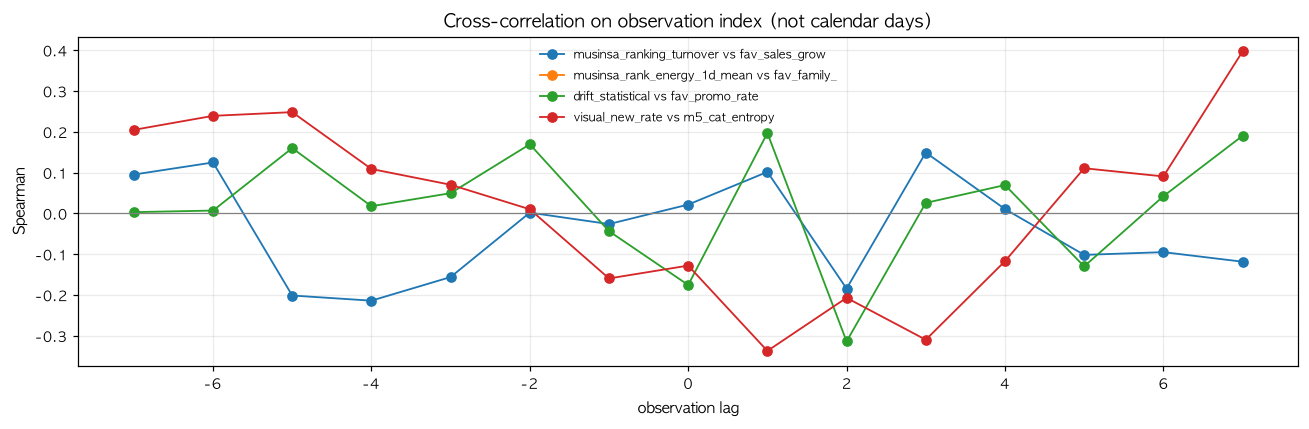

In [7]:
pair_left = [
    "musinsa_rank_energy_1d_mean",
    "musinsa_ranking_turnover",
    "musinsa_mix_js",
    "musinsa_cat_entropy",
    "visual_new_rate",
    "drift_statistical",
    "drift_text",
]
pair_right = [
    "fav_sales_growth",
    "fav_promo_rate",
    "fav_family_entropy",
    "fav_family_mix_js",
    "m5_units_growth",
    "m5_cat_entropy",
]


def corr_table(df: pd.DataFrame, lefts, rights) -> pd.DataFrame:
    rows = []
    for a in lefts:
        for b in rights:
            if a not in df.columns or b not in df.columns:
                continue
            sub = df[[a, b]].apply(pd.to_numeric, errors="coerce").dropna()
            if len(sub) < 6 or sub[a].nunique() < 2 or sub[b].nunique() < 2:
                pear = spear = np.nan
            else:
                pear = float(sub[a].corr(sub[b], method="pearson"))
                spear = float(sub[a].corr(sub[b], method="spearman"))
            rows.append({"left": a, "right": b, "n": int(len(sub)), "pearson": pear, "spearman": spear})
    return pd.DataFrame(rows).sort_values("spearman", key=lambda s: s.abs(), ascending=False)


simult = corr_table(labeled, pair_left, pair_right)
print("simultaneous correlation (synthetic alignment)")
display(simult.head(16))


def partial_spearman(df, a, b, controls):
    ctrl = [c for c in controls if c not in (a, b)]
    cols = [a, b, *ctrl]
    work = df[cols].apply(pd.to_numeric, errors="coerce").dropna()
    if sklearn is None or len(work) < 8 or not ctrl:
        return np.nan, len(work)
    if work[a].nunique() < 2 or work[b].nunique() < 2:
        return np.nan, len(work)
    lr = LinearRegression()
    z = work[ctrl].to_numpy()
    ra = work[a].to_numpy() - lr.fit(z, work[a]).predict(z)
    rb = work[b].to_numpy() - lr.fit(z, work[b]).predict(z)
    return _spearman(ra, rb), len(work)


controls = [c for c in ("weekday", "month", "fav_promo_rate") if c in labeled.columns]
partial_rows = []
for rec in simult.head(10).itertuples():
    rho, n = partial_spearman(labeled, rec.left, rec.right, controls)
    partial_rows.append({"left": rec.left, "right": rec.right, "spearman": rec.spearman, "partial_spearman": rho, "n": n, "controls": ",".join(controls)})
print("partial Spearman (calendar + promo)")
display(pd.DataFrame(partial_rows))


def lag_corr(df, a, b, lags=range(-7, 8)) -> pd.DataFrame:
    rows = []
    sa = pd.to_numeric(df[a], errors="coerce")
    sb = pd.to_numeric(df[b], errors="coerce")
    for lag in lags:
        if lag < 0:
            x, y = sa.iloc[-lag:], sb.iloc[:lag]
        elif lag > 0:
            x, y = sa.iloc[:-lag], sb.iloc[lag:]
        else:
            x, y = sa, sb
        aligned = pd.concat([x.reset_index(drop=True), y.reset_index(drop=True)], axis=1).dropna()
        aligned.columns = ["x", "y"]
        rows.append({"lag": lag, "n": int(len(aligned)), "spearman": _spearman(aligned["x"].to_numpy(), aligned["y"].to_numpy())})
    return pd.DataFrame(rows)


focus_pairs = [
    ("musinsa_ranking_turnover", "fav_sales_growth"),
    ("musinsa_rank_energy_1d_mean", "fav_family_mix_js"),
    ("drift_statistical", "fav_promo_rate"),
    ("visual_new_rate", "m5_cat_entropy"),
]
lag_frames = []
for a, b in focus_pairs:
    if a in labeled.columns and b in labeled.columns:
        lc = lag_corr(labeled, a, b)
        lc["pair"] = f"{a} vs {b}"
        lag_frames.append(lc)
        print(f"lead-lag {a} vs {b} (lag>0 ⇒ right leads)")
        display(lc)

if lag_frames:
    fig, ax = plt.subplots(figsize=(12, 4))
    for frame in lag_frames:
        ax.plot(frame["lag"], frame["spearman"], marker="o", label=frame["pair"].iloc[0][:42])
    ax.axhline(0, color="0.5", lw=0.8)
    ax.set_xlabel("observation lag")
    ax.set_ylabel("Spearman")
    ax.set_title("Cross-correlation on observation index (not calendar days)")
    ax.legend(frameon=False, fontsize=8)
    finish_figure(fig, ax)


PCA explained variance ratio [0.188 0.116 0.09  0.085]
PC1 loadings (abs top 10) — common co-movement, not a named cause


,pc1,pc2
elapsed_days,0.326365,0.010687
musinsa_price_median,0.318967,0.028969
month,0.318796,0.020441
musinsa_n,0.312889,0.085722
fav_sales_vol_7,-0.310318,0.014577
musinsa_rank_energy_sustained_mean,-0.263869,-0.118718
cm29_cat_entropy,0.242989,-0.154780
cm29_top1_share,-0.234399,0.160702
cm29_n,0.224797,-0.037830
musinsa_discount_median,-0.214737,-0.164497


PC2 loadings (abs top 10)


,pc1,pc2
weekday,0.056591,0.344293
m5_units_growth,0.023890,0.320580
musinsa_cat_entropy,0.057240,-0.289354
cm29_price_median,0.026819,-0.287617
musinsa_cat_hhi,-0.144496,0.282874
musinsa_top1_share,-0.041325,0.266283
gap_days,-0.058846,-0.246203
fav_sales_growth,-0.121489,0.194666
musinsa_momentum_span_mean,-0.128269,-0.192271
visual_churn_rate,0.098612,-0.181390


PC1 candidate label: 수요/공개변동성
PC2 candidate label: 수요/공개변동성 · 구성교체


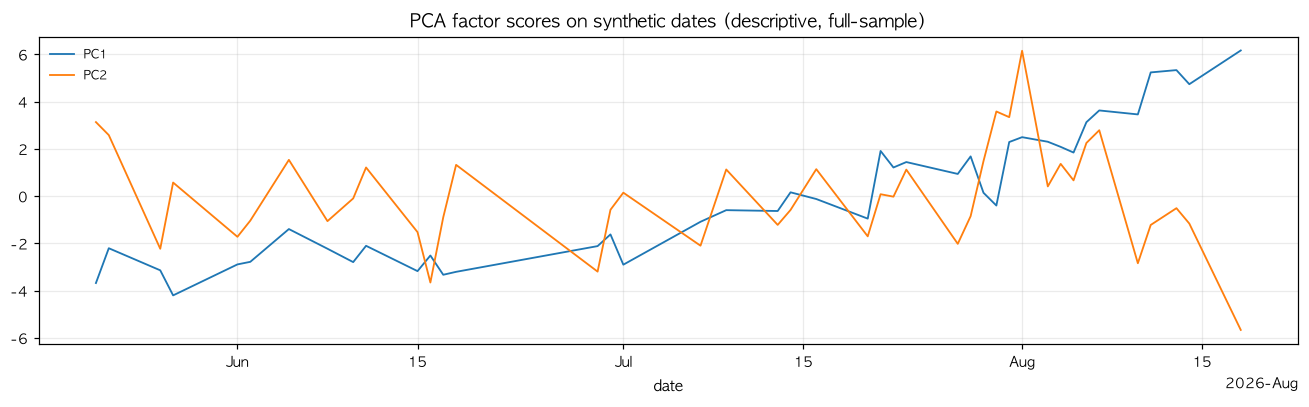


Ablation: silhouette-only vs +public (from walk-forward table)


,target,include_public,model,n_eval,mae,mae_vs_persistence,dir_acc,spearman
7,y_future_drift_score,False,elasticnet,27,0.124438,-0.005739,1.000000,-0.128609
10,y_future_drift_score,True,elasticnet,27,0.124438,-0.005739,1.000000,-0.128609
8,y_future_drift_score,False,hgb,27,0.110870,-0.019307,1.000000,0.377272
11,y_future_drift_score,True,hgb,27,0.115406,-0.014771,1.000000,0.387048
6,y_future_drift_score,False,persistence,27,0.130177,0.000000,1.000000,0.267737
9,y_future_drift_score,True,persistence,27,0.130177,0.000000,1.000000,0.267737
13,y_future_sales_growth,False,elasticnet,27,0.114703,0.006587,0.555556,-0.349817
16,y_future_sales_growth,True,elasticnet,27,0.110318,0.002202,0.555556,-0.326007
14,y_future_sales_growth,False,hgb,27,0.128464,0.020347,0.555556,0.145910
17,y_future_sales_growth,True,hgb,27,0.126400,0.018283,0.592593,0.213675


public-feature lift (positive mae_lift = public helped)


,target,model,mae_silhouette_only,mae_plus_public,mae_lift,spearman_silhouette_only,spearman_plus_public,n_eval
0,y_future_drift_score,elasticnet,0.124438,0.124438,0.000000e+00,-0.128609,-0.128609,27
1,y_future_drift_score,hgb,0.110870,0.115406,-4.535622e-03,0.377272,0.387048,27
2,y_future_drift_score,persistence,0.130177,0.130177,0.000000e+00,0.267737,0.267737,27
3,y_future_sales_growth,elasticnet,0.114703,0.110318,4.384941e-03,-0.349817,-0.326007,27
4,y_future_sales_growth,hgb,0.128464,0.126400,2.063755e-03,0.145910,0.213675,27
5,y_future_sales_growth,persistence,0.108117,0.108117,0.000000e+00,0.542125,0.542125,27
6,y_rank_mix_proxy,elasticnet,0.145890,0.145890,3.309643e-09,0.492214,0.492214,27
7,y_rank_mix_proxy,hgb,0.092218,0.096849,-4.631541e-03,0.574962,0.608855,27
8,y_rank_mix_proxy,persistence,0.050970,0.050970,0.000000e+00,0.798014,0.798014,27


In [8]:
pca_cols = [c for c in SILHOUETTE_FEATURES + PUBLIC_FEATURES if c in labeled.columns]
pca_x = labeled[pca_cols].apply(pd.to_numeric, errors="coerce")
if sklearn is None:
    print("skip PCA")
    pca_loadings = pd.DataFrame()
else:
    imp = SimpleImputer(strategy="median")
    sc = StandardScaler()
    z = sc.fit_transform(imp.fit_transform(pca_x))
    pca = PCA(n_components=min(4, z.shape[1], z.shape[0] - 1), random_state=42)
    scores = pca.fit_transform(z)
    print("PCA explained variance ratio", np.round(pca.explained_variance_ratio_, 3))
    pca_loadings = pd.DataFrame(pca.components_[:2].T, index=pca_cols, columns=["pc1", "pc2"])
    print("PC1 loadings (abs top 10) — common co-movement, not a named cause")
    display(pca_loadings.reindex(pca_loadings["pc1"].abs().sort_values(ascending=False).head(10).index))
    print("PC2 loadings (abs top 10)")
    display(pca_loadings.reindex(pca_loadings["pc2"].abs().sort_values(ascending=False).head(10).index))

    def name_factor(load: pd.Series) -> str:
        keys = load.abs().sort_values(ascending=False).head(5).index.tolist()
        blob = " ".join(keys)
        tags = []
        if any(k.startswith("fav_") or k.startswith("m5_") for k in keys):
            tags.append("수요/공개변동성")
        if "promo" in blob:
            tags.append("프로모션")
        if any(s in blob for s in ("mix", "entropy", "turnover", "rank_energy", "hhi")):
            tags.append("구성교체")
        return " · ".join(tags) or "혼합 공통변동"

    print("PC1 candidate label:", name_factor(pca_loadings["pc1"]))
    print("PC2 candidate label:", name_factor(pca_loadings["pc2"]))
    score_df = pd.DataFrame(scores[:, :2], columns=["pc1", "pc2"])
    score_df["synthetic_date"] = labeled["synthetic_date"].to_numpy()
    fig, ax = plt.subplots(figsize=(12, 3.8))
    ax.plot(score_df["synthetic_date"], score_df["pc1"], label="PC1")
    ax.plot(score_df["synthetic_date"], score_df["pc2"], label="PC2")
    ax.set_title("PCA factor scores on synthetic dates (descriptive, full-sample)")
    ax.legend(frameon=False)
    finish_figure(fig, ax, date_axis=True)

print("\nAblation: silhouette-only vs +public (from walk-forward table)")
if sklearn is not None and "metrics_all" in globals():
    ab = metrics_all.copy()
    display(ab.sort_values(["target", "model", "include_public"]))
    lift_rows = []
    for (target, model), g in ab.groupby(["target", "model"]):
        g = g.set_index("include_public")
        if False in g.index and True in g.index:
            lift_rows.append(
                {
                    "target": target,
                    "model": model,
                    "mae_silhouette_only": float(g.loc[False, "mae"]),
                    "mae_plus_public": float(g.loc[True, "mae"]),
                    "mae_lift": float(g.loc[False, "mae"] - g.loc[True, "mae"]),
                    "spearman_silhouette_only": float(g.loc[False, "spearman"]),
                    "spearman_plus_public": float(g.loc[True, "spearman"]),
                    "n_eval": int(g.loc[True, "n_eval"]),
                }
            )
    lift = pd.DataFrame(lift_rows)
    print("public-feature lift (positive mae_lift = public helped)")
    display(lift)
else:
    lift = pd.DataFrame()
    print("ablation skipped")


## 5. Offset · 순열 placebo

공개 시계열을 ±30/±60일 밀고, 같은 공개 블록을 날짜와 무관하게 순열한다. 선택한 임시 정렬에서만 커지는 상관·예측 lift인지 본다.


placebo comparison


,variant,offset_days,n,spearman_turnover_vs_sales_growth,mae_hgb,mae_persistence,n_eval
0,anchor_offset_0,0.0,41,0.021603,0.096849,0.05097,27
1,anchor_offset_-60,-60.0,41,-0.098258,0.085357,0.05097,27
2,anchor_offset_-30,-30.0,41,0.217596,0.095289,0.05097,27
3,anchor_offset_30,30.0,41,-0.237631,0.088175,0.05097,27
4,anchor_offset_60,60.0,41,0.059756,0.092409,0.05097,27
5,permutation_0,NaN,41,-0.140070,0.092417,0.05097,27
6,permutation_1,NaN,41,0.100871,0.105166,0.05097,27
7,permutation_2,NaN,41,0.201742,0.106199,0.05097,27
8,permutation_3,NaN,41,0.258362,0.104832,0.05097,27
9,permutation_4,NaN,41,0.120557,0.094181,0.05097,27


observed spearman 0.021602787456445997
permutation mean/std 0.1082926829268293 0.15259676259030072


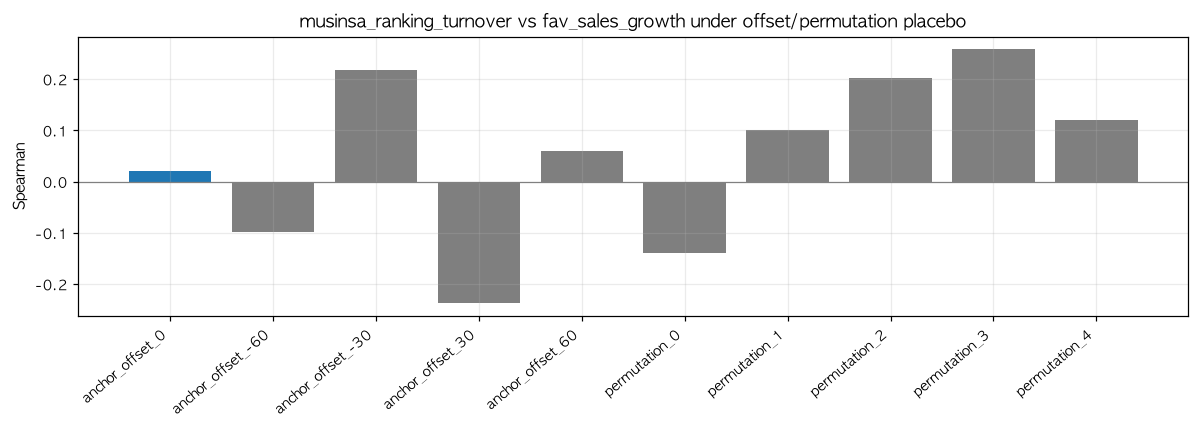

In [9]:
FOCUS_LEFT = "musinsa_ranking_turnover"
FOCUS_RIGHT = "fav_sales_growth"


def focus_spearman(panel: pd.DataFrame) -> dict:
    work = attach_horizon_targets(panel)
    sub = work[[FOCUS_LEFT, FOCUS_RIGHT]].apply(pd.to_numeric, errors="coerce").dropna()
    rho = _spearman(sub[FOCUS_LEFT].to_numpy(), sub[FOCUS_RIGHT].to_numpy()) if len(sub) else np.nan
    out = {"n": int(len(sub)), "spearman_turnover_vs_sales_growth": rho}
    if sklearn is not None:
        wf = walk_forward(work, "y_rank_mix_proxy", include_public=True, min_train=12)
        m = wf["metrics"]
        if not m.empty:
            out["mae_hgb"] = float(m.loc[m["model"] == "hgb", "mae"].iloc[0])
            out["mae_persistence"] = float(m.loc[m["model"] == "persistence", "mae"].iloc[0])
            out["n_eval"] = int(m.loc[m["model"] == "hgb", "n_eval"].iloc[0])
    return out


placebo_rows = []
base_stats = focus_spearman(joint)
placebo_rows.append({"variant": "anchor_offset_0", "offset_days": 0, **base_stats})
for off in (-60, -30, 30, 60):
    try:
        alt = build_joint_panel(silhouette, fav_state, m5_state, offset_days=off)
        stats_off = focus_spearman(alt)
        placebo_rows.append({"variant": f"anchor_offset_{off}", "offset_days": off, **stats_off})
    except Exception as exc:
        placebo_rows.append({"variant": f"anchor_offset_{off}", "offset_days": off, "error": f"{type(exc).__name__}: {exc}"})
        traceback.print_exc()

rng = np.random.default_rng(42)
for i in range(5):
    perm = permute_public_block(joint, rng)
    stats_p = focus_spearman(perm)
    placebo_rows.append({"variant": f"permutation_{i}", "offset_days": np.nan, **stats_p})

placebo = pd.DataFrame(placebo_rows)
print("placebo comparison")
display(placebo)

obs = placebo.loc[placebo["variant"] == "anchor_offset_0", "spearman_turnover_vs_sales_growth"]
perm_vals = placebo.loc[placebo["variant"].astype(str).str.startswith("permutation_"), "spearman_turnover_vs_sales_growth"]
print("observed spearman", float(obs.iloc[0]) if len(obs) else np.nan)
print("permutation mean/std", float(perm_vals.mean()) if len(perm_vals) else np.nan, float(perm_vals.std()) if len(perm_vals) else np.nan)

fig, ax = plt.subplots(figsize=(11, 4))
lab = placebo["variant"]
ax.bar(range(len(placebo)), placebo["spearman_turnover_vs_sales_growth"].fillna(0), color=["C0" if v == "anchor_offset_0" else "C7" for v in lab])
ax.set_xticks(range(len(placebo)))
ax.set_xticklabels(lab, rotation=40, ha="right")
ax.axhline(0, color="0.5", lw=0.8)
ax.set_ylabel("Spearman")
ax.set_title(f"{FOCUS_LEFT} vs {FOCUS_RIGHT} under offset/permutation placebo")
finish_figure(fig, ax)


## 6. 파이프라인 검증 vs 현실 인과에 추가로 필요한 것

아래 셀은 이 실행에서 **실제로 관측된** 숫자만 모아 두 덩어리로 나눈다.

1. **파이프라인 검증 결과** — shape, 유효 표본, 모델 MAE, loading/lag, placebo 민감도
2. **현실 인과 검증에 추가로 필요한 것** — 동기간 매출·프로모션·재고 정답. 이 노트북만으로는 한국 패션 시장의 원인을 주장할 수 없다.


In [10]:
print("=" * 72)
print("A. 파이프라인 검증 결과 (이 실행에서 관측)")
print("=" * 72)
print("silhouette days:", int(silhouette["run_date"].nunique()), "shape", silhouette.shape)
print("joint shape:", joint.shape, "| synthetic_alignment all true:", bool(joint["synthetic_alignment"].all()))
print("label_ready:", int(labeled["label_ready"].sum()), "/", len(labeled))
for col in TARGETS:
    print(f"  {col}: n={int(labeled[col].notna().sum())}")
print("X features:", len(feat_names), "X shape on labeled:", x_all.shape)
print("numeric_panel musinsa ok days:", int((silhouette["musinsa_status"] == "ok").sum()), "/ 42  ← early days are insufficient_n, not hidden")
print("rank_energy coverage:", int(silhouette["musinsa_rank_energy_1d_mean"].notna().sum()), "/ 42")
if sklearn is not None and "metrics_all" in globals():
    print("walk-forward metrics:")
    display(metrics_all)
    if "lift" in globals() and not lift.empty:
        print("ablation lift:")
        display(lift)
if "simult" in globals():
    print("top |spearman| pairs:")
    display(simult.head(8))
if "placebo" in globals():
    print("placebo table:")
    display(placebo)
    obs_rho = placebo.loc[placebo["variant"] == "anchor_offset_0", "spearman_turnover_vs_sales_growth"]
    perm_rho = placebo.loc[placebo["variant"].astype(str).str.startswith("permutation_"), "spearman_turnover_vs_sales_growth"]
    if len(obs_rho) and len(perm_rho.dropna()):
        print(
            "placebo note: observed Spearman",
            round(float(obs_rho.iloc[0]), 3),
            "vs permutation mean",
            round(float(perm_rho.mean()), 3),
        )

print()
print("=" * 72)
print("B. 현실 인과 검증에 추가로 필요한 동기간 데이터")
print("=" * 72)
print("- 2026 관측일과 겹치는 한국 패션 채널의 실제 매출/단위/프로모션 (동기간 GMV)")
print("- 순위 변동의 교란항: 수집 커버리지 변화, 카테고리 리뉴얼, 광고 집행")
print("- 합성 앵커(2016 Favorita / 2015 M5)를 대체할 동일 달력의 외부 수요")
print("- 이 노트북의 상관·예측 lift는 상대시간 샌드박스 민감도이지 인과 효과 크기가 아니다")
print("done")


A. 파이프라인 검증 결과 (이 실행에서 관측)
silhouette days: 42 shape (42, 56)
joint shape: (42, 84) | synthetic_alignment all true: True
label_ready: 39 / 42
  y_rank_mix_proxy: n=39
  y_future_drift_score: n=39
  y_future_sales_growth: n=39
X features: 42 X shape on labeled: (42, 42)
numeric_panel musinsa ok days: 19 / 42  ← early days are insufficient_n, not hidden
rank_energy coverage: 42 / 42
walk-forward metrics:


,target,include_public,model,n_eval,mae,mae_vs_persistence,dir_acc,spearman
0,y_rank_mix_proxy,False,persistence,27,0.050970,0.000000,1.000000,0.798014
1,y_rank_mix_proxy,False,elasticnet,27,0.145890,0.094920,1.000000,0.492214
2,y_rank_mix_proxy,False,hgb,27,0.092218,0.041247,1.000000,0.574962
3,y_rank_mix_proxy,True,persistence,27,0.050970,0.000000,1.000000,0.798014
4,y_rank_mix_proxy,True,elasticnet,27,0.145890,0.094920,1.000000,0.492214
5,y_rank_mix_proxy,True,hgb,27,0.096849,0.045879,1.000000,0.608855
6,y_future_drift_score,False,persistence,27,0.130177,0.000000,1.000000,0.267737
7,y_future_drift_score,False,elasticnet,27,0.124438,-0.005739,1.000000,-0.128609
8,y_future_drift_score,False,hgb,27,0.110870,-0.019307,1.000000,0.377272
9,y_future_drift_score,True,persistence,27,0.130177,0.000000,1.000000,0.267737


ablation lift:


,target,model,mae_silhouette_only,mae_plus_public,mae_lift,spearman_silhouette_only,spearman_plus_public,n_eval
0,y_future_drift_score,elasticnet,0.124438,0.124438,0.000000e+00,-0.128609,-0.128609,27
1,y_future_drift_score,hgb,0.110870,0.115406,-4.535622e-03,0.377272,0.387048,27
2,y_future_drift_score,persistence,0.130177,0.130177,0.000000e+00,0.267737,0.267737,27
3,y_future_sales_growth,elasticnet,0.114703,0.110318,4.384941e-03,-0.349817,-0.326007,27
4,y_future_sales_growth,hgb,0.128464,0.126400,2.063755e-03,0.145910,0.213675,27
5,y_future_sales_growth,persistence,0.108117,0.108117,0.000000e+00,0.542125,0.542125,27
6,y_rank_mix_proxy,elasticnet,0.145890,0.145890,3.309643e-09,0.492214,0.492214,27
7,y_rank_mix_proxy,hgb,0.092218,0.096849,-4.631541e-03,0.574962,0.608855,27
8,y_rank_mix_proxy,persistence,0.050970,0.050970,0.000000e+00,0.798014,0.798014,27


top |spearman| pairs:


,left,right,n,pearson,spearman
26,visual_new_rate,fav_family_entropy,42,-0.191342,-0.400859
28,visual_new_rate,m5_units_growth,42,-0.174446,-0.376550
24,visual_new_rate,fav_sales_growth,42,-0.300620,-0.375253
7,musinsa_ranking_turnover,fav_promo_rate,41,-0.327860,-0.347038
19,musinsa_cat_entropy,fav_promo_rate,19,0.184683,0.291228
38,drift_text,fav_family_entropy,42,0.319939,0.278249
36,drift_text,fav_sales_growth,42,0.336454,0.274760
23,musinsa_cat_entropy,m5_cat_entropy,19,-0.285921,-0.268421


placebo table:


,variant,offset_days,n,spearman_turnover_vs_sales_growth,mae_hgb,mae_persistence,n_eval
0,anchor_offset_0,0.0,41,0.021603,0.096849,0.05097,27
1,anchor_offset_-60,-60.0,41,-0.098258,0.085357,0.05097,27
2,anchor_offset_-30,-30.0,41,0.217596,0.095289,0.05097,27
3,anchor_offset_30,30.0,41,-0.237631,0.088175,0.05097,27
4,anchor_offset_60,60.0,41,0.059756,0.092409,0.05097,27
5,permutation_0,NaN,41,-0.140070,0.092417,0.05097,27
6,permutation_1,NaN,41,0.100871,0.105166,0.05097,27
7,permutation_2,NaN,41,0.201742,0.106199,0.05097,27
8,permutation_3,NaN,41,0.258362,0.104832,0.05097,27
9,permutation_4,NaN,41,0.120557,0.094181,0.05097,27


placebo note: observed Spearman 0.022 vs permutation mean 0.108

B. 현실 인과 검증에 추가로 필요한 동기간 데이터
- 2026 관측일과 겹치는 한국 패션 채널의 실제 매출/단위/프로모션 (동기간 GMV)
- 순위 변동의 교란항: 수집 커버리지 변화, 카테고리 리뉴얼, 광고 집행
- 합성 앵커(2016 Favorita / 2015 M5)를 대체할 동일 달력의 외부 수요
- 이 노트북의 상관·예측 lift는 상대시간 샌드박스 민감도이지 인과 효과 크기가 아니다
done
